# 4. EV-GAN: a GAN designed for heavy tails

This notebook compares a standard GAN with the **EV-GAN** construction of Allouche, Girard, and Gobet (2022), using a one-dimensional heavy-tailed Burr distribution.

The notation continues directly from the earlier notebooks:

- $X\in\mathbb{R}$ is the observed random variable;
- $Z\sim\pi$ is the latent vector;
- $G_\theta(Z)=\widetilde X$ is a generated observation;
- $D_\phi(x)$ discriminates real from generated observations.

For both models we now use a higher-dimensional bounded latent vector,

$$
Z\sim U([0,1]^{d'}), \qquad d'=1.
$$

For EV-GAN, the first latent coordinate $U=Z^{(1)}$ enters the inverse-TIF transformation, while the whole vector $Z$ enters the ReLU network.

The important difference between the two models remains the **parametrisation of the generator**.

> **Source note.** The mathematical construction follows pp. 11–16 of the supplied EV-GAN slides and the EV-GAN paper. The numerical settings below are chosen to be closer to the configurations used in the paper while keeping the notebook practical for a workshop.

## Learning objectives

By the end of this notebook you should be able to:

1. explain why a standard ReLU GAN with bounded latent input struggles with an unbounded heavy-tailed distribution;
2. define the Tail-Index Function (TIF);
3. derive the inverse-TIF transformation used by EV-GAN;
4. construct an EV-GAN generator in PyTorch;
5. train a standard GAN and EV-GAN under the same adversarial loss;
6. compare their ability to reproduce extreme quantiles.

In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt
import torch

from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from scipy.special import expi

SEED = 123

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device(
    "mps" if torch.backends.mps.is_available()
    else "cuda" if torch.cuda.is_available()
    else "cpu"
)

print("PyTorch version:", torch.__version__)
print("Device:", device)

PyTorch version: 2.2.1
Device: mps


# 1. A heavy-tailed target distribution

The slides use Burr distributions to illustrate the difficulty faced by ordinary ReLU generators.

We parameterise a Burr XII distribution by the extreme-value parameters

$$
\gamma > 0,
\qquad
\rho < 0,
$$

using

$$
c=-\frac{\rho}{\gamma},
\qquad
d_B=-\frac{1}{\rho}.
$$

Its quantile function is

$$
q(u)
=
\left\{(1-u)^{-1/d_B}-1\right\}^{1/c},
\qquad 0<u<1.
$$

We take

$$
\gamma=0.5,
\qquad
\rho=-3.
$$

The choice $\rho=-3$ is useful for the workshop because it lies in the regime $\rho<-2$, where the corrected TIF has the $C^2$ regularity used in the clean $O(J^{-2})$ ReLU approximation argument.

We also use $n=10{,}000$ observations.

In [60]:
gamma = 0.5
rho = -3.0

d_prime = 1
J_G = 64
J_D = 32

BATCH_SIZE = 32
LR_G = 5e-4
LR_D = 5e-4

N_STEPS = 3000
CHECK_EVERY = 250
SEEDS = [123, 456, 789]

def burr_quantile(u, gamma=gamma, rho=rho):
    u = np.asarray(u)
    c = -rho / gamma
    d_burr = -1.0 / rho
    return ((1.0 - u) ** (-1.0 / d_burr) - 1.0) ** (1.0 / c)

n = 10_000
U_data = np.random.uniform(size=n)
X = burr_quantile(U_data).astype(np.float32).reshape(-1, 1)

print("Sample size:", n)
print("gamma:", gamma, "rho:", rho)
print("latent dimension d' =", d_prime)
print("Sample median:", np.median(X))
print("Sample 0.99 quantile:", np.quantile(X, 0.99))
print("Sample maximum:", X.max())

Sample size: 10000
gamma: 0.5 rho: -3.0
latent dimension d' = 1
Sample median: 1.3844857
Sample 0.99 quantile: 9.767976322174073
Sample maximum: 252.46797


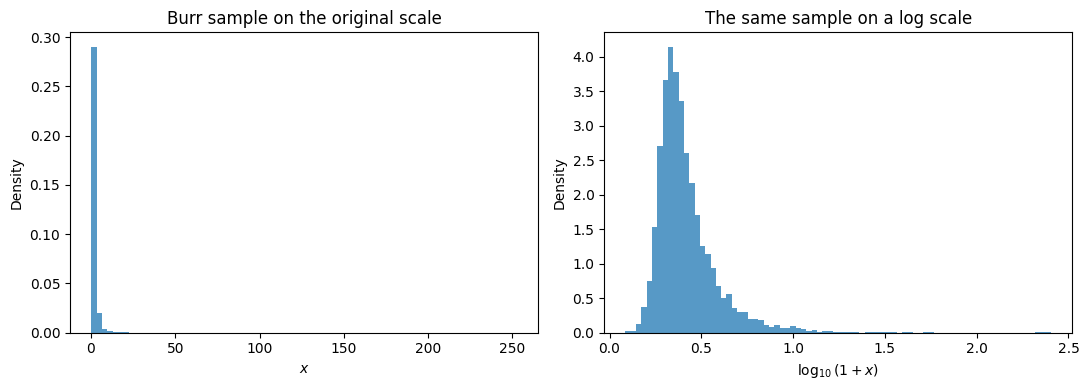

In [61]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].hist(X.ravel(), bins=80, density=True, alpha=0.75)
axes[0].set_xlabel(r"$x$")
axes[0].set_ylabel("Density")
axes[0].set_title("Burr sample on the original scale")

axes[1].hist(np.log10(1 + X.ravel()), bins=80, density=True, alpha=0.75)
axes[1].set_xlabel(r"$\log_{10}(1+x)$")
axes[1].set_ylabel("Density")
axes[1].set_title("The same sample on a log scale")

plt.tight_layout()
plt.show()

# 2. Why the standard GAN has a structural tail problem

Suppose

$$
Z\sim U([0,1]^{d'})
$$

and a standard generator $G_\theta$ is a finite ReLU network.

For fixed parameters $\theta$, $G_\theta$ is continuous. Since $[0,1]^{d'}$ is compact,

$$
G_\theta([0,1]^{d'})
$$

is bounded.

Therefore a standard generator with bounded latent input **cannot have an unbounded heavy tail**.

Increasing the latent dimension gives the network more flexibility, but it does **not** remove this structural bounded-support limitation.

# 3. The Tail-Index Function

For a heavy-tailed distribution with quantile function $q$, the slides introduce

$$
f^{\mathrm{TIF}}(u)
= H_u(q(u))=
-\frac{\log q(u)}
{\log\left(\frac{1-u^2}{2}\right)},
\qquad 0<u<1.
$$

Although

$$
q(u)\longrightarrow\infty
\qquad\text{as }u\to1,
$$

the Tail-Index Function remains bounded and satisfies

$$
f^{\mathrm{TIF}}(u)\longrightarrow\gamma
\qquad\text{as }u\to1.
$$

This is the key idea: **rather than asking a ReLU network to approximate an unbounded quantile function, ask it to approximate a bounded TIF.**

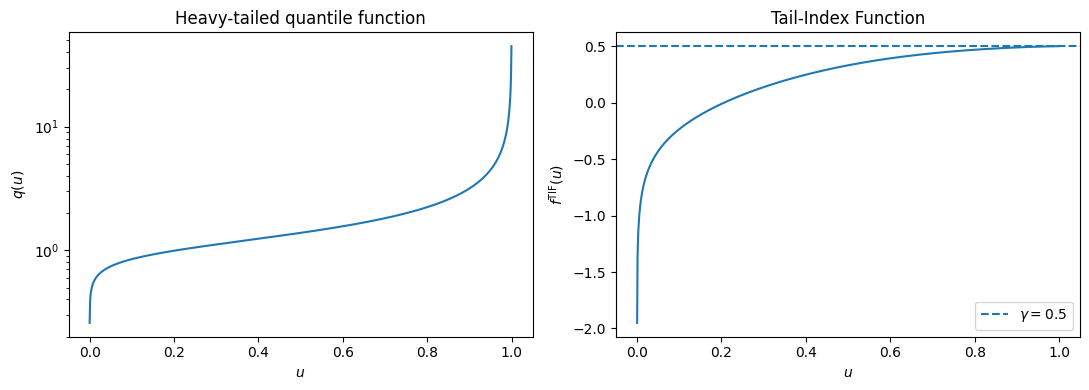

In [62]:
u_grid = np.linspace(1e-4, 0.9995, 1000)
q_true = burr_quantile(u_grid)

f_tif_true = (
    -np.log(q_true)
    / np.log((1.0 - u_grid**2) / 2.0)
)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(u_grid, q_true)
axes[0].set_xlabel(r"$u$")
axes[0].set_ylabel(r"$q(u)$")
axes[0].set_yscale("log")
axes[0].set_title("Heavy-tailed quantile function")

axes[1].plot(u_grid, f_tif_true)
axes[1].axhline(gamma, linestyle="--", label=rf"$\gamma={gamma}$")
axes[1].set_xlabel(r"$u$")
axes[1].set_ylabel(r"$f^{\mathrm{TIF}}(u)$")
axes[1].set_title("Tail-Index Function")
axes[1].legend()

plt.tight_layout()
plt.show()

# 4. Inverting the TIF

Rearranging the definition gives
$$
q(u)
=
\left(
\frac{1-u^2}{2}
\right)^{-f^{\mathrm{TIF}}(u)}.
$$

For a latent vector
$$
Z=(Z^{(1)},\ldots,Z^{(d')}) \in (0,1)^{d'},
$$
define
$$
U = Z^{(1)}.
$$

The neural network produces an estimate
$$
\widehat f_{\theta}^{\mathrm{TIF}}(Z),
$$
while $U$ determines the inverse-TIF transformation. Thus, the
one-dimensional EV-GAN generator has the form
$$
Z
\longmapsto
\widehat f_{\theta}^{\mathrm{TIF}}(Z)
\longmapsto
\left(
\frac{1-U^2}{2}
\right)^{-\widehat f_{\theta}^{\mathrm{TIF}}(Z)}
=
\widetilde X.
$$

In [63]:
class TIFInverse(nn.Module):
    # H_u^{-1}(x) = ((1-u^2)/2)^(-x)

    def forward(self, u, x):
        # Avoid evaluating exactly at the boundary u=1.
        u = u.clamp(1e-6, 1 - 1e-6)

        log_base = torch.log((1.0 - u.pow(2)) / 2.0)

        # Work on the log scale before exponentiating.
        # The upper clamp is only a numerical overflow guard.
        log_output = (-x * log_base).clamp(max=20.0)

        return torch.exp(log_output)

# 5. The standard GAN generator

For a fair comparison, both models use

$$
Z\sim U([0,1]^{d'}).
$$

The standard generator is a one-hidden-layer ReLU network,

$$
G_\theta^{\mathrm{GAN}}:[0,1]^{d'}\to\mathbb{R}.
$$

The final layer is linear. Its output is still necessarily bounded for fixed $\theta$ because the latent domain is compact.

In [64]:
class StandardGenerator(nn.Module):
    def __init__(self, d_prime=d_prime, J=J_G):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(d_prime, J),
            nn.ReLU(),
            nn.Linear(J, 1)
        )
        nn.init.normal_(self.layers[-1].weight, mean=0.0, std=0.02)
        nn.init.constant_(self.layers[-1].bias, 0.5)

    def forward(self, z):
        return self.layers(z)

# 6. The EV-GAN generator

The key step in EV-GAN is **not** to approximate the unbounded quantile function $q(u)$ directly. Instead, it approximates a suitably corrected version of the bounded Tail-Index Function (TIF).

Recall that

$$
f^{\mathrm{TIF}}(u)
=
-\frac{\log q(u)}
{\log\left(\frac{1-u^2}{2}\right)},
\qquad 0<u<1,
$$

and, for a regularly varying upper tail,

$$
f^{\mathrm{TIF}}(u)\longrightarrow\gamma
\qquad\text{as }u\to1.
$$

So the difficult divergence of $q(u)$ as $u\to1$ has been replaced by the problem of approximating a bounded function.

## 6.1 Why introduce a corrected TIF?

Boundedness alone is enough for a universal approximation result, but EV-GAN aims for a **quantitative approximation rate**. For this it is useful to make the target function smoother near the boundaries.

The slides define the corrected TIF as

$$
f^{\mathrm{CTIF}}(u)
=
f^{\mathrm{TIF}}(u)
-
\sum_{k=1}^{6}\kappa_k e_k(u),
$$

where

- $e_1,\ldots,e_6$ are fixed functions that do not depend on the unknown distribution;
- $\kappa_1,\ldots,\kappa_6$ are distribution-dependent coefficients.

The correction removes the leading boundary behaviour of the TIF. Under the regularity assumptions in the EV-GAN construction,

$$
f^{\mathrm{CTIF}}\in C^0([0,1]),
$$

and, under the second-order condition with parameter $\rho$,

$$
\rho<-1
\quad\Longrightarrow\quad
f^{\mathrm{CTIF}}\in C^1([0,1]),
$$

while

$$
\rho<-2
\quad\Longrightarrow\quad
f^{\mathrm{CTIF}}\in C^2([0,1]).
$$

This extra smoothness is important because a smooth one-dimensional function can be approximated efficiently by a piecewise-linear ReLU network.

> **Important:** the neural network approximates the **CTIF**. The six correction terms are then added back to recover an approximation to the original TIF.

## 6.2 Approximating the CTIF with ReLUs

A ReLU network is piecewise linear. A useful building block is the triangular ``hat'' function

$$
\widehat{\sigma}^{R}(t)
=
\sigma^R(t+1)
-
2\sigma^R(t)
+
\sigma^R(t-1),
$$

where

$$
\sigma^R(t)=\max(0,t).
$$

This triangular function can therefore be represented using only **three shifted ReLUs**.

Now divide $[0,1]$ into $M$ equally spaced intervals,

$$
t_j=j\delta,
\qquad
\delta=\frac{1}{M},
\qquad
j=0,\ldots,M.
$$

For a sufficiently smooth function $f$, a piecewise-linear approximation can be written using translated and rescaled copies of the hat function. In the construction used in the slides,

$$
f(t)
\approx
\sum_{j=0}^{M}
f(t_j)
\widehat{\sigma}^{R}
\left(
\frac{t-t_j}{\delta}
\right).
$$

If $f\in C^2([0,1])$, the uniform approximation error is

$$
\sup_{t\in[0,1]}
\left|
f(t)-\widehat f(t)
\right|
=
O(M^{-2}).
$$

Each triangular basis function requires three ReLUs, so

$$
J=3(M+1).
$$

Consequently,

$$
O(M^{-2})=O(J^{-2}).
$$

This explains the role of the CTIF correction:

1. the raw quantile $q(u)$ is unbounded near $u=1$;
2. the TIF is bounded;
3. the CTIF is made smoother by removing explicit boundary terms;
4. the smooth CTIF can then be approximated by a ReLU network at rate $O(J^{-2})$ when $\rho<-2$.

After approximating the CTIF, EV-GAN adds the correction terms back:

$$
\widehat f^{\mathrm{TIF}}_\theta(u)
=
N_\theta(u)
+
\sum_{k=1}^{6}\kappa_k e_k(u),
$$

where $N_\theta$ is the ReLU-network approximation to $f^{\mathrm{CTIF}}$.

Thus, in the one-dimensional case,

$$
\sup_{u\in[0,1]}
\left|
f^{\mathrm{TIF}}(u)
-
\widehat f^{\mathrm{TIF}}_\theta(u)
\right|
=
O(J^{-2}),
\qquad \rho<-2.
$$

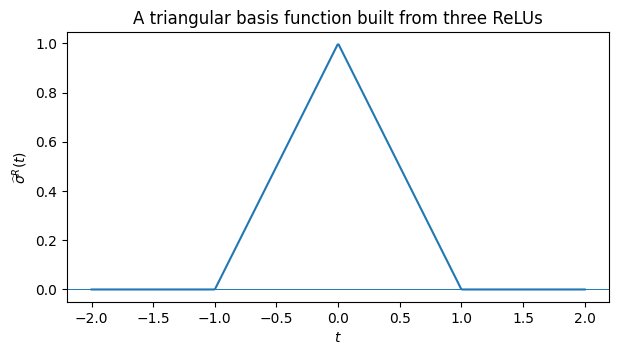

In [65]:
# The triangular basis used in the ReLU approximation argument

def relu_hat(t):
    return (
        torch.relu(t + 1.0)
        - 2.0 * torch.relu(t)
        + torch.relu(t - 1.0)
    )

t_hat = torch.linspace(-2.0, 2.0, 500)

plt.figure(figsize=(7, 3.5))
plt.plot(t_hat.numpy(), relu_hat(t_hat).numpy())
plt.axhline(0, linewidth=0.7)
plt.xlabel(r"$t$")
plt.ylabel(r"$\widehat{\sigma}^R(t)$")
plt.title("A triangular basis function built from three ReLUs")
plt.show()

## 6.3 How the correction appears in the implementation
The functions $e_1,\ldots,e_6$ are fixed correction functions chosen so that
$$
f^{\mathrm{CTIF}}(u)
=
f^{\mathrm{TIF}}(u)
-
\sum_{k=1}^6 \kappa_k e_k(u)
$$
has improved boundary regularity.
The neural network is used to approximate the smoother corrected TIF,
$
f^{\mathrm{CTIF}}(u),
$
while the correction terms are added back explicitly to recover the TIF:
$$
\widehat f_{\theta}^{\mathrm{TIF}}(u)
=
N_{\theta}(u)
+
\sum_{k=1}^6 \kappa_k e_k(u).
$$

Define
$$
p_{01}(u)
=
-4u^5+5u^4,
\qquad
p_{00}(u)
=
u^3-2u^2+u.
$$

The six correction functions can be written as
$$
e_1(u)
=
p_{01}(u),
$$
$$
e_2(u)
=
\frac{p_{01}(u)}
{\log(1-u)},
$$
$$
e_3(u)
=
p_{01}(u)\,
\operatorname{li}(1-u),
$$
$$
e_4(u)
=
p_{01}(u)
\left\{
\frac{1-u}{\log(1-u)}
-
\operatorname{li}(1-u)
\right\},
$$
$$
e_5(u)
=
p_{01}(u)
\left\{
\frac{(1-u)\{\log(1-u)+1\}}
{2\log^2(1-u)}
-
\frac{1}{2}\operatorname{li}(1-u)
\right\},
$$
and
$$
e_6(u)
=
p_{00}(u),
$$
for 
$$
\operatorname{li}(u) = \int^u_0\frac{\mathrm{d}t}{\log t}.
$$
Hence,
$$
\sum_{k=1}^6 \kappa_k e_k(u)
=
p_{01}(u)
\left\{
\kappa_1+\Phi(u)
\right\}
+
\kappa_6 p_{00}(u),
$$
where
$$
\begin{aligned}
\Phi(u)
={}&
\frac{\kappa_2}{\log(1-u)}
+
\kappa_3\,\operatorname{li}(1-u)
\\
&+
\kappa_4
\left\{
\frac{1-u}{\log(1-u)}
-
\operatorname{li}(1-u)
\right\}
\\
&+
\kappa_5
\left\{
\frac{(1-u)\{\log(1-u)+1\}}
{2\log^2(1-u)}
-
\frac{1}{2}\operatorname{li}(1-u)
\right\}.
\end{aligned}
$$

In the implementation,
```
neural_part = self.layers(z)
```
approximates $f^{\mathrm{CTIF}}$, while
```
tif_corr_1 = self.correction_tif_1(u)
tif_corr_2 = self.correction_tif_2(u)
```
represent the correction
$$
\sum_{k=1}^6 \kappa_k e_k(u).
$$

Thus,
```
network_tif = neural_part + tif_corr_1 + tif_corr_2
```
approximates
$$
f^{\mathrm{TIF}}(u)
=
f^{\mathrm{CTIF}}(u)
+
\sum_{k=1}^6 \kappa_k e_k(u).
$$

The functions $e_k$ are therefore not themselves the second-order
regular variation terms. Rather, they are fixed analytic correction
functions designed to absorb the boundary behaviour induced by the
tail expansion, leaving a smoother corrected TIF for the ReLU network
to approximate.

In [66]:
class EVGenerator(nn.Module):
    def __init__(self, d_prime=d_prime, J=J_G, li_table_size=4096):
        super().__init__()

        self.layers = nn.Sequential(
            nn.Linear(d_prime, J),
            nn.ReLU(),
            nn.Linear(J, 1)
        )

        self.tif_inverse = TIFInverse()

         # Define the \kappa_k's
        self.var1 = nn.Parameter(torch.tensor([[0.25]]))
        self.var2 = nn.Parameter(torch.zeros(1, 1))
        self.var3 = nn.Parameter(torch.zeros(1, 1))
        self.var4 = nn.Parameter(torch.zeros(1, 1))
        self.var5 = nn.Parameter(torch.zeros(1, 1))
        self.var6 = nn.Parameter(torch.zeros(1, 1))

        nn.init.normal_(self.layers[-1].weight, mean=0.0, std=0.01)
        nn.init.constant_(self.layers[-1].bias, 0.15)

        # Precompute the fixed li(1-u) function once for speed.
        self.li_table_size = li_table_size
        self.u_min = 1e-5
        self.u_max = 1.0 - 1e-5

        grid = np.linspace(
            self.u_min,
            self.u_max,
            li_table_size,
            dtype=np.float64
        )
        values = expi(np.log(1.0 - grid)).astype(np.float32)

        self.register_buffer(
            "_li_table",
            torch.tensor(values, dtype=torch.float32).reshape(-1, 1)
        )

    @staticmethod
    def p01(u):
        return -4.0 * u**5 + 5.0 * u**4

    @staticmethod
    def p00(u):
        return u**3 - 2.0 * u**2 + u

    def li_one_minus_u(self, u):
        pos = (
            (u - self.u_min)
            / (self.u_max - self.u_min)
            * (self.li_table_size - 1)
        )

        i0 = torch.floor(pos).long().clamp(0, self.li_table_size - 2)
        weight = pos - i0.to(pos.dtype)

        v0 = self._li_table[i0.squeeze(-1)]
        v1 = self._li_table[(i0 + 1).squeeze(-1)]

        return v0 + (v1 - v0) * weight

    def Phi(self, u):
        one_minus_u = (1.0 - u).clamp_min(1e-6)
        log_term = torch.log(one_minus_u)
        li_term = self.li_one_minus_u(u)

        term1 = self.var2 / log_term
        term2 = self.var3 * li_term
        term3 = self.var4 * (one_minus_u / log_term - li_term)
        term4 = self.var5 * (
            one_minus_u * (log_term + 1.0) / (2.0 * log_term**2)
            - li_term / 2.0
        )

        return term1 + term2 + term3 + term4

    def corrected_tif(self, z):
        z = z.clamp(1e-5, 1.0 - 1e-5)
        u = z[:, [0]]

        neural_part = self.layers(z)

        correction_1 = self.p01(u) * (self.var1 + self.Phi(u))
        correction_1 = torch.nan_to_num(
            correction_1,
            nan=0.0,
            posinf=0.0,
            neginf=0.0
        )

        correction_2 = self.var6 * self.p00(u)

        # No outer ReLU: the TIF can be negative away from the upper tail.
        return neural_part + correction_1 + correction_2

    def forward(self, z):
        z = z.clamp(1e-5, 1.0 - 1e-5)
        u = z[:, [0]]
        f_tif = self.corrected_tif(z)
        return self.tif_inverse(u, f_tif)

## Inspect the two generators before training

**Standard GAN**

$$
Z\in[0,1]^{d'}
\rightarrow
\text{ReLU network}
\rightarrow
\widetilde X.
$$

**EV-GAN**

$$
Z\in[0,1]^{d'}
\rightarrow
\text{ReLU + TIF corrections}
\rightarrow
\widehat f_\theta^{\mathrm{TIF}}(Z)
\rightarrow
H_{Z^{(1)}}^{-1}
\rightarrow
\widetilde X.
$$

In [67]:
G_gan = StandardGenerator().to(device)
G_ev = EVGenerator().to(device)

print("Standard GAN generator")
print(G_gan)

print("\nEV-GAN generator")
print(G_ev)

Standard GAN generator
StandardGenerator(
  (layers): Sequential(
    (0): Linear(in_features=1, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=1, bias=True)
  )
)

EV-GAN generator
EVGenerator(
  (layers): Sequential(
    (0): Linear(in_features=1, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=1, bias=True)
  )
  (tif_inverse): TIFInverse()
)


# 7. Use the same discriminator for both models

To isolate the effect of the generator parametrisation, we use the same discriminator architecture and the same adversarial loss for the two models.

As in the earlier notebooks, the discriminator returns a **logit** and we use `BCEWithLogitsLoss` for numerical stability.

In [68]:
class Discriminator(nn.Module):
    def __init__(self, J=J_D):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(1, J),
            nn.ReLU(),
            nn.Linear(J, J),
            nn.ReLU(),
            nn.Linear(J, 1)
        )

    def forward(self, x):
        return self.layers(x).squeeze(-1)

# 8. Adversarial training

The adversarial objective is unchanged, and we continue to use the non-saturating generator loss.

The revised numerical setup uses

$$
d'=1,\qquad
J_G=64,\qquad
J_D=32,
$$

with batch size 32 and learning rates $5\times10^{-4}$.

Th generator is checkpointed during training and the checkpoint with the smallest upper-tail MSLE is retained. We also perform fitting over an ensemble of random weight initialisations, and retain the average performer.


The final iterate of a GAN need not be its best iterate, so checkpoint selection gives a much more stable workshop comparison.

In [69]:
def sample_Z(n):
    return torch.rand(
        n,
        d_prime,
        device=device
    ).clamp(1e-5, 1.0 - 1e-5)


def tail_msle(reference, generated, xi=0.99):
    reference = np.asarray(reference).ravel()
    generated = np.asarray(generated).ravel()

    k = max(
        1,
        int(np.ceil((1.0 - xi) * min(len(reference), len(generated))))
    )

    x_ref = np.sort(reference)[-k:]
    x_gen = np.sort(generated)[-k:]

    x_ref = np.maximum(x_ref, 1e-12)
    x_gen = np.maximum(x_gen, 1e-12)

    return np.mean((np.log(x_ref) - np.log(x_gen)) ** 2)


def simulate_from_generator(generator, n_sim=10_000, seed=2026):
    torch.manual_seed(seed)

    with torch.no_grad():
        z = sample_Z(n_sim)
        out = generator(z).cpu().numpy().ravel()

    return out


def train_gan(
    generator,
    data,
    n_steps=N_STEPS,
    batch_size=BATCH_SIZE,
    lr_G=LR_G,
    lr_D=LR_D,
    seed=123,
    check_every=CHECK_EVERY,
    selection_xi=0.99
):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    generator = generator.to(device)
    discriminator = Discriminator().to(device)

    opt_G = torch.optim.Adam(generator.parameters(), lr=lr_G)
    opt_D = torch.optim.Adam(discriminator.parameters(), lr=lr_D)

    criterion = nn.BCEWithLogitsLoss()

    data_tensor = torch.tensor(
        data,
        dtype=torch.float32,
        device=device
    )

    history_G = []
    history_D = []
    history_step = []

    block_G = []
    block_D = []

    best_score = np.inf
    best_step = None
    best_state = None

    for step in range(1, n_steps + 1):

        idx = torch.randint(
            0,
            data_tensor.shape[0],
            (batch_size,),
            device=device
        )
        x_real = data_tensor[idx]

        # 1. Update discriminator
        z = sample_Z(batch_size)
        x_fake = generator(z).detach()

        logits_real = discriminator(x_real)
        logits_fake = discriminator(x_fake)

        loss_D = (
            criterion(logits_real, torch.ones_like(logits_real))
            +
            criterion(logits_fake, torch.zeros_like(logits_fake))
        )

        opt_D.zero_grad()
        loss_D.backward()
        opt_D.step()

        # 2. Update generator
        z = sample_Z(batch_size)
        x_fake = generator(z)
        logits_fake = discriminator(x_fake)

        loss_G = criterion(
            logits_fake,
            torch.ones_like(logits_fake)
        )

        opt_G.zero_grad()
        loss_G.backward()
        opt_G.step()

        block_D.append(loss_D.item())
        block_G.append(loss_G.item())

        if step % check_every == 0:

            history_step.append(step)
            history_D.append(np.mean(block_D))
            history_G.append(np.mean(block_G))
            block_D = []
            block_G = []

            generated_check = simulate_from_generator(
                generator,
                n_sim=len(data),
                seed=10_000 + step
            )

            score = tail_msle(
                data,
                generated_check,
                xi=selection_xi
            )

            if np.isfinite(score) and score < best_score:
                best_score = score
                best_step = step
                best_state = {
                    key: value.detach().cpu().clone()
                    for key, value in generator.state_dict().items()
                }

            if step % (4 * check_every) == 0:
                print(
                    f"step {step:5d}/{n_steps} | "
                    f"loss_D={history_D[-1]:.3f} | "
                    f"loss_G={history_G[-1]:.3f} | "
                    f"best MSLE({selection_xi:.2f})={best_score:.4f}"
                )

    if best_state is not None:
        generator.load_state_dict(best_state)

    return (
        generator,
        discriminator,
        history_G,
        history_D,
        history_step,
        best_score,
        best_step
    )


def fit_seed_ensemble(
    generator_factory,
    model_name,
    data=X,
    seeds=SEEDS
):
    results = []

    for seed in seeds:
        print(f"\n{model_name}: seed {seed}")

        torch.manual_seed(seed)
        generator = generator_factory()

        result = train_gan(
            generator,
            data,
            seed=seed
        )

        (
            fitted_G,
            fitted_D,
            hist_G,
            hist_D,
            hist_step,
            best_score,
            best_step
        ) = result

        results.append({
            "seed": seed,
            "G": fitted_G,
            "D": fitted_D,
            "hist_G": hist_G,
            "hist_D": hist_D,
            "hist_step": hist_step,
            "score": best_score,
            "best_step": best_step
        })

        print(
            f"selected checkpoint: step {best_step}; "
            f"MSLE(0.99)={best_score:.4f}"
        )

    scores = np.array([r["score"] for r in results])
    order = np.argsort(scores)

    chosen = results[order[len(order) // 2]]

    print(f"\n{model_name} seed summary")
    for r in sorted(results, key=lambda x: x["score"]):
        print(
            f"seed={r['seed']:3d} | "
            f"MSLE(0.99)={r['score']:.4f} | "
            f"checkpoint={r['best_step']}"
        )

    print(
        f"Using median-score run: seed {chosen['seed']} "
        f"(MSLE={chosen['score']:.4f})"
    )

    return chosen, results

## Train the standard GAN

The default fits three seeds and uses the median tail-score run for the subsequent plots.

For a faster live demonstration, temporarily use

```python
SEEDS = [123]
N_STEPS = 3000
```

In [70]:
chosen_gan, runs_gan = fit_seed_ensemble(
    lambda: StandardGenerator(),
    "Standard GAN"
)

G_gan = chosen_gan["G"]
D_gan = chosen_gan["D"]
hist_G_gan = chosen_gan["hist_G"]
hist_D_gan = chosen_gan["hist_D"]
hist_step_gan = chosen_gan["hist_step"]


Standard GAN: seed 123
step  1000/3000 | loss_D=1.323 | loss_G=0.741 | best MSLE(0.99)=2.6571
step  2000/3000 | loss_D=1.325 | loss_G=0.759 | best MSLE(0.99)=2.6571
step  3000/3000 | loss_D=1.331 | loss_G=0.733 | best MSLE(0.99)=2.6061
selected checkpoint: step 2500; MSLE(0.99)=2.6061

Standard GAN: seed 456
step  1000/3000 | loss_D=1.344 | loss_G=0.894 | best MSLE(0.99)=2.4341
step  2000/3000 | loss_D=1.331 | loss_G=0.738 | best MSLE(0.99)=2.4341
step  3000/3000 | loss_D=1.334 | loss_G=0.730 | best MSLE(0.99)=2.4341
selected checkpoint: step 500; MSLE(0.99)=2.4341

Standard GAN: seed 789
step  1000/3000 | loss_D=1.320 | loss_G=0.744 | best MSLE(0.99)=3.1874
step  2000/3000 | loss_D=1.312 | loss_G=0.775 | best MSLE(0.99)=2.8368
step  3000/3000 | loss_D=1.322 | loss_G=0.726 | best MSLE(0.99)=2.8368
selected checkpoint: step 1750; MSLE(0.99)=2.8368

Standard GAN seed summary
seed=456 | MSLE(0.99)=2.4341 | checkpoint=500
seed=123 | MSLE(0.99)=2.6061 | checkpoint=2500
seed=789 | MSLE(0.99

## Train EV-GAN

EV-GAN uses the same seed set, discriminator width, batch size, learning rates and checkpoint rule. The generator parametrisation is the substantive difference.

In [71]:
chosen_ev, runs_ev = fit_seed_ensemble(
    lambda: EVGenerator(),
    "EV-GAN"
)

G_ev = chosen_ev["G"]
D_ev = chosen_ev["D"]
hist_G_ev = chosen_ev["hist_G"]
hist_D_ev = chosen_ev["hist_D"]
hist_step_ev = chosen_ev["hist_step"]


EV-GAN: seed 123
step  1000/3000 | loss_D=1.388 | loss_G=0.685 | best MSLE(0.99)=0.0963
step  2000/3000 | loss_D=1.387 | loss_G=0.695 | best MSLE(0.99)=0.0397
step  3000/3000 | loss_D=1.389 | loss_G=0.692 | best MSLE(0.99)=0.0397
selected checkpoint: step 1500; MSLE(0.99)=0.0397

EV-GAN: seed 456
step  1000/3000 | loss_D=1.385 | loss_G=0.693 | best MSLE(0.99)=0.0583
step  2000/3000 | loss_D=1.385 | loss_G=0.705 | best MSLE(0.99)=0.0403
step  3000/3000 | loss_D=1.385 | loss_G=0.689 | best MSLE(0.99)=0.0403
selected checkpoint: step 1750; MSLE(0.99)=0.0403

EV-GAN: seed 789
step  1000/3000 | loss_D=1.376 | loss_G=0.704 | best MSLE(0.99)=0.0341
step  2000/3000 | loss_D=1.388 | loss_G=0.693 | best MSLE(0.99)=0.0266
step  3000/3000 | loss_D=1.386 | loss_G=0.691 | best MSLE(0.99)=0.0266
selected checkpoint: step 1250; MSLE(0.99)=0.0266

EV-GAN seed summary
seed=789 | MSLE(0.99)=0.0266 | checkpoint=1250
seed=123 | MSLE(0.99)=0.0397 | checkpoint=1500
seed=456 | MSLE(0.99)=0.0403 | checkpoint=

# 9. Compare training losses

The loss curves are useful diagnostics, but they are **not** the primary criterion here.

The scientific question is whether the generated distribution reproduces the heavy upper tail.

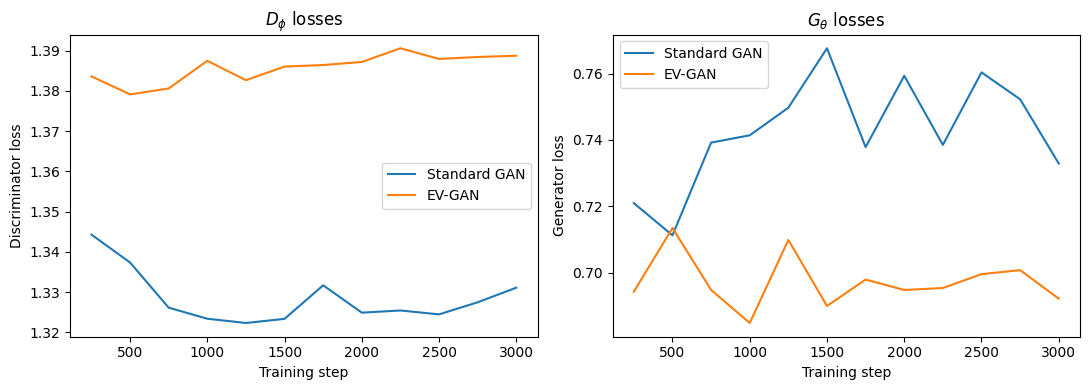

In [72]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(hist_step_gan, hist_D_gan, label="Standard GAN")
axes[0].plot(hist_step_ev, hist_D_ev, label="EV-GAN")
axes[0].set_xlabel("Training step")
axes[0].set_ylabel("Discriminator loss")
axes[0].set_title(r"$D_\phi$ losses")
axes[0].legend()

axes[1].plot(hist_step_gan, hist_G_gan, label="Standard GAN")
axes[1].plot(hist_step_ev, hist_G_ev, label="EV-GAN")
axes[1].set_xlabel("Training step")
axes[1].set_ylabel("Generator loss")
axes[1].set_title(r"$G_\theta$ losses")
axes[1].legend()

plt.tight_layout()
plt.show()

# 10. Generate a large comparison sample

In [73]:
n_sim = 100_000

X_gan = simulate_from_generator(
    G_gan,
    n_sim=n_sim,
    seed=30_001
)

X_ev = simulate_from_generator(
    G_ev,
    n_sim=n_sim,
    seed=30_002
)

X_real = X.ravel()

print(
    "Fraction of negative standard-GAN draws:",
    np.mean(X_gan < 0)
)

Fraction of negative standard-GAN draws: 0.0


## Compare the bulk

On the original scale, the large tail values make histograms difficult to read. A $\log(1+x)$ transformation lets us compare the central part of the distributions.

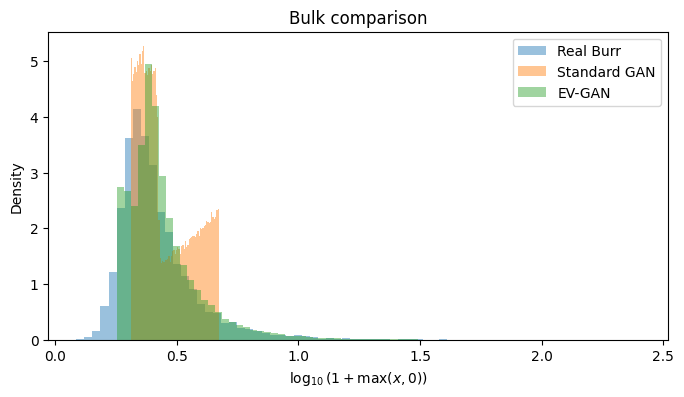

In [74]:
plt.figure(figsize=(8, 4))

plt.hist(
    np.log10(1 + X_real),
    bins=70,
    density=True,
    alpha=0.45,
    label="Real Burr"
)

plt.hist(
    np.log10(1 + np.maximum(X_gan, 0)),
    bins=70,
    density=True,
    alpha=0.45,
    label="Standard GAN"
)

plt.hist(
    np.log10(1 + np.maximum(X_ev, 0)),
    bins=70,
    density=True,
    alpha=0.45,
    label="EV-GAN"
)

plt.xlabel(r"$\log_{10}(1+\max(x,0))$")
plt.ylabel("Density")
plt.title("Bulk comparison")
plt.legend()
plt.show()

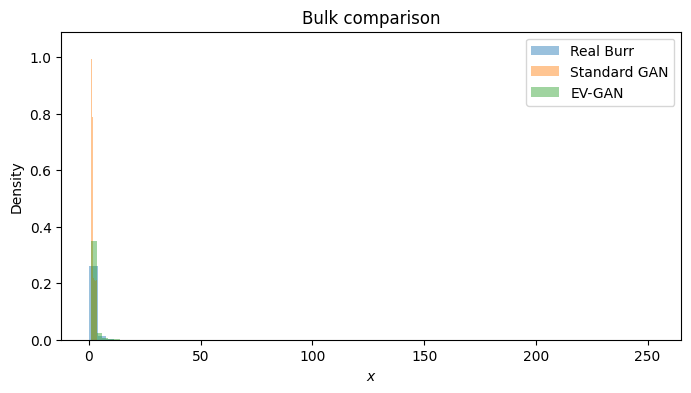

In [75]:
plt.figure(figsize=(8, 4))

plt.hist(
     X_real,
    bins=70,
    density=True,
    alpha=0.45,
    label="Real Burr"
)

plt.hist(
    X_gan,
    bins=70,
    density=True,
    alpha=0.45,
    label="Standard GAN"
)

plt.hist(
  X_ev,
    bins=70,
    density=True,
    alpha=0.45,
    label="EV-GAN"
)

plt.xlabel(r"$x$")
plt.ylabel("Density")
plt.title("Bulk comparison")
plt.legend()
plt.show()

# 11. Compare upper quantiles

For extreme-value applications, the upper quantiles are much more revealing.

We compare:

- the theoretical Burr quantile $q(p)$;
- the empirical quantile of the training data;
- the standard GAN quantile;
- the EV-GAN quantile.

In [76]:
probs = np.array([
    0.50,
    0.90,
    0.95,
    0.99,
    0.995,
    0.999
])

q_theory = burr_quantile(probs)
q_data = np.quantile(X_real, probs)
q_gan = np.quantile(X_gan, probs)
q_ev = np.quantile(X_ev, probs)

print(
    f"{'p':>8} "
    f"{'Theory':>12} "
    f"{'Data':>12} "
    f"{'GAN':>12} "
    f"{'EV-GAN':>12}"
)

for p, qt, qd, qg, qe in zip(
    probs, q_theory, q_data, q_gan, q_ev
):
    print(
        f"{p:8.3f} "
        f"{qt:12.3f} "
        f"{qd:12.3f} "
        f"{qg:12.3f} "
        f"{qe:12.3f}"
    )

       p       Theory         Data          GAN       EV-GAN
   0.500        1.383        1.384        1.582        1.539
   0.900        3.162        3.079        3.238        3.256
   0.950        4.472        4.365        3.470        4.484
   0.990       10.000        9.768        3.657        9.260
   0.995       14.142       13.730        3.681       12.736
   0.999       31.623       29.588        3.699       25.875


The key comparison is towards $p=1$.

A standard GAN can give a reasonable-looking fit in the centre while its high quantiles flatten because the generator has bounded output.

EV-GAN has a mechanism that permits the generated observations to continue increasing into the tail.

# 12. Log-quantile plot

For a regularly varying tail,

$$
q(p)\approx (1-p)^{-\gamma}L\left(\frac{1}{1-p}\right).
$$

Taking logarithms gives approximately

$$
\log q(p)
\approx
\gamma[-\log(1-p)]
+
\text{slowly varying term}.
$$

Thus a plot of

$$
-\log(1-p)
\quad\text{against}\quad
\log q(p)
$$

is particularly informative in the upper tail. Its asymptotic slope is $\gamma$.

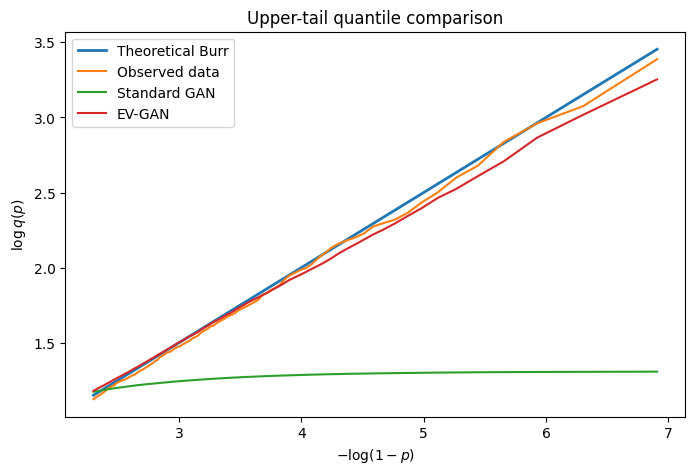

In [77]:
p_tail = np.linspace(0.90, 0.999, 120)

q_theory_tail = burr_quantile(p_tail)
q_data_tail = np.quantile(X_real, p_tail)
q_gan_tail = np.quantile(X_gan, p_tail)
q_ev_tail = np.quantile(X_ev, p_tail)

x_tail = -np.log(1.0 - p_tail)

plt.figure(figsize=(8, 5))

plt.plot(x_tail, np.log(q_theory_tail), label="Theoretical Burr", linewidth=2)
plt.plot(x_tail, np.log(q_data_tail), label="Observed data")
plt.plot(x_tail, np.log(np.maximum(q_gan_tail, 1e-8)), label="Standard GAN")
plt.plot(x_tail, np.log(np.maximum(q_ev_tail, 1e-8)), label="EV-GAN")

plt.xlabel(r"$-\log(1-p)$")
plt.ylabel(r"$\log q(p)$")
plt.title("Upper-tail quantile comparison")
plt.legend()
plt.show()

# 13. Tail-error summaries

The checkpoint selection above uses the empirical **upper-tail MSLE**.

For additional interpretation in this simulated example, where the true Burr quantile is known, we also calculate

$$
\mathrm{RMSE}_{\log q}
=
\left[
\frac{1}{|\mathcal P|}
\sum_{p\in\mathcal P}
\left\{
\log \widehat q(p)-\log q(p)
\right\}^2
\right]^{1/2}.
$$

In [78]:
def log_quantile_rmse(sample, probs):
    q_hat = np.quantile(sample, probs)
    q_true = burr_quantile(probs)

    return np.sqrt(
        np.mean(
            (
                np.log(np.maximum(q_hat, 1e-12))
                -
                np.log(q_true)
            ) ** 2
        )
    )

print("Empirical upper-tail MSLE")
for xi in [0.90, 0.95, 0.99]:
    print(
        f"xi={xi:.2f}: "
        f"GAN={tail_msle(X_real, X_gan, xi):.4f}, "
        f"EV-GAN={tail_msle(X_real, X_ev, xi):.4f}"
    )

print("\nTheoretical log-quantile RMSE")
for threshold in [0.90, 0.95, 0.99]:
    p = np.linspace(threshold, 0.999, 100)

    err_gan = log_quantile_rmse(X_gan, p)
    err_ev = log_quantile_rmse(X_ev, p)

    print(
        f"p >= {threshold:.2f}: "
        f"GAN RMSE = {err_gan:.3f}, "
        f"EV-GAN RMSE = {err_ev:.3f}"
    )

Empirical upper-tail MSLE
xi=0.90: GAN=0.3741, EV-GAN=1.1049
xi=0.95: GAN=0.7373, EV-GAN=1.0402
xi=0.99: GAN=2.5939, EV-GAN=0.7873

Theoretical log-quantile RMSE
p >= 0.90: GAN RMSE = 0.580, EV-GAN RMSE = 0.042
p >= 0.95: GAN RMSE = 0.799, EV-GAN RMSE = 0.056
p >= 0.99: GAN RMSE = 1.406, EV-GAN RMSE = 0.110


# 14. What happens as the tail coordinate approaches 1?

For the standard GAN the whole latent domain $[0,1]$ is compact, so the fitted output remains bounded.

For EV-GAN, the first coordinate $U=Z^{(1)}$ appears inside

$$
G_\theta^{\mathrm{EV}}(Z)
=
\left(
\frac{1-U^2}{2}
\right)^{-\widehat f_\theta^{\mathrm{TIF}}(Z)}.
$$

To visualise this mechanism, we vary $U$ towards one and hold the other 31 latent coordinates fixed at $0.5$.

In [79]:
u_extreme = np.array([
    0.90,
    0.99,
    0.999,
    0.9999,
    0.99999
], dtype=np.float32)

z_extreme = torch.full(
    (len(u_extreme), d_prime),
    0.5,
    dtype=torch.float32,
    device=device
)
z_extreme[:, 0] = torch.tensor(u_extreme, device=device)

with torch.no_grad():
    g_standard = G_gan(z_extreme).cpu().numpy().ravel()
    g_ev = G_ev(z_extreme).cpu().numpy().ravel()
    tif_ev = G_ev.corrected_tif(z_extreme).cpu().numpy().ravel()

print(
    f"{'u':>10} "
    f"{'q_Burr(u)':>14} "
    f"{'G_GAN slice':>14} "
    f"{'f_TIF_EV':>14} "
    f"{'G_EV slice':>14}"
)

for u, gs, ft, ge in zip(
    u_extreme,
    g_standard,
    tif_ev,
    g_ev
):
    qt = burr_quantile(float(u))

    print(
        f"{u:10.5f} "
        f"{qt:14.3f} "
        f"{gs:14.3f} "
        f"{ft:14.3f} "
        f"{ge:14.3f}"
    )

         u      q_Burr(u)    G_GAN slice       f_TIF_EV     G_EV slice
   0.90000          3.162          3.242          0.503          3.270
   0.99000         10.000          3.657          0.487          9.448
   0.99900         31.623          3.699          0.481         27.753
   0.99990         99.992          3.703          0.478         81.984
   0.99999        316.013          3.703          0.477        242.273


## Plot the learned TIF


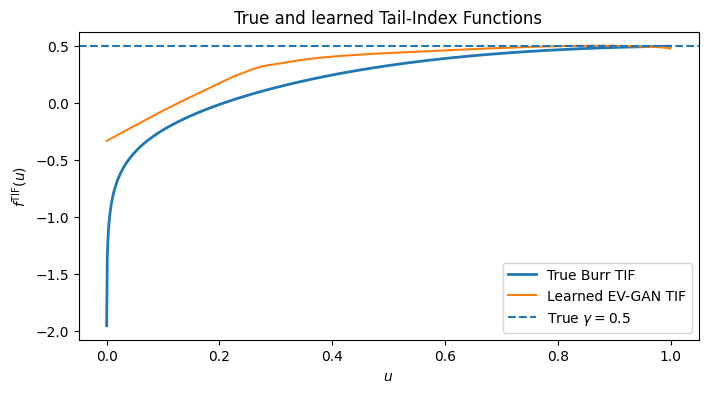

In [80]:
u_plot = torch.linspace(
    1e-4,
    0.9995,
    300,
    device=device
)

# For d' = 1, the latent vector is just u itself
z_plot = u_plot.reshape(-1, 1)

with torch.no_grad():
    learned_tif = (
        G_ev.corrected_tif(z_plot)
        .squeeze(-1)
        .cpu()
        .numpy()
    )

u_plot_np = u_plot.cpu().numpy()

plt.figure(figsize=(8, 4))

plt.plot(
    u_grid,
    f_tif_true,
    label="True Burr TIF",
    linewidth=2
)

plt.plot(
    u_plot_np,
    learned_tif,
    label="Learned EV-GAN TIF"
)

plt.axhline(
    gamma,
    linestyle="--",
    label=rf"True $\gamma={gamma}$"
)

plt.xlabel(r"$u$")
plt.ylabel(r"$f^{\mathrm{TIF}}(u)$")
plt.title("True and learned Tail-Index Functions")
plt.legend()
plt.show()

# 15. Main lesson

The standard GAN and EV-GAN are trained using the same adversarial principle.

The crucial difference is the generator parametrisation.

### Standard GAN

$$
G_\theta^{\mathrm{GAN}}(Z)
=
\text{one-hidden-layer ReLU network},
\qquad
Z\in[0,1].
$$

Its fitted output remains bounded because its latent domain is compact.

### EV-GAN

$$
G_\theta^{\mathrm{EV}}(Z)
=
H_{Z^{(1)}}^{-1}
\left(
\widehat f_\theta^{\mathrm{TIF}}(Z)
\right).
$$

The ReLU network and CTIF correction learn a bounded TIF-like quantity, while the final transformation builds in the heavy-tail mechanism.

The revised setup also illustrates an important practical GAN lesson: **checkpoint selection and repeated seeds matter**.

# 16. Workshop exercises

### Exercise A — make the tail heavier

Change `gamma = 0.5` to `gamma = 0.9`, regenerate the data and retrain both models.

### Exercise B — remove the CTIF correction

Inside `EVGenerator.corrected_tif`, replace

```python
return neural_part + correction_1 + correction_2
```

by

```python
return neural_part
```

and compare the tail fit.

### Exercise C — weaken the second-order regularity

The default is now `rho = -3.0`. Try `rho = -1.0` instead.

### Exercise D — inspect seed variability

Compare the stored runs in

```python
runs_gan
runs_ev
```

and inspect their MSLE scores and selected checkpoint locations.

### Exercise E — compare more extreme quantiles

Increase the generated sample size and compare

$$
q(0.99),\quad q(0.999),\quad q(0.9999).
$$

# References

Allouche, M., Girard, S. and Gobet, E. (2022). **EV-GAN: Simulation of extreme events with ReLU neural networks.** *Journal of Machine Learning Research*, 23(150), 1–39.

The notation and theoretical development in this notebook are aligned with the supplied workshop slides, particularly the TIF, CTIF and EV-GAN generator construction on pp. 11–16.